In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

### Reading bleaching rate data

In [37]:
identifiers = ['1e1', '1e2', '1e3', '1e4']
bleaching_times_all_A = []
fingerprints_all_A = []

for _ in identifiers:
    fingerprints_all_A.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    bleaching_times_all_A.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\bl_rate"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        for id in identifiers:
            if id in file:
                bleaching_times_all_A[identifiers.index(id)] = np.load(file)
                break
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_A[identifiers.index(id)] += data.sum(axis=1)
                break

for i, fingerprint in enumerate(fingerprints_all_A):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_A[i] = fingerprint

In [ ]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_A = []
for fingerprint in fingerprints_all_A:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_A.append([param.value for param in result.params.values()])

### Reading ON to OFF data

In [35]:
identifiers = ['red1', 'red01', 'red005', 'red001']
bleaching_times_all_B = []
fingerprints_all_B = []

for _ in identifiers:
    fingerprints_all_B.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    bleaching_times_all_B.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\off_prob"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        for id in identifiers:
            if id in file:
                bleaching_times_all_B[identifiers.index(id)] = np.load(file)
                break
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_B[identifiers.index(id)] += data.sum(axis=1)
                break

for i, fingerprint in enumerate(fingerprints_all_B):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_B[i] = fingerprint

In [61]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_B = []
for fingerprint in fingerprints_all_B:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_B.append([param.value for param in result.params.values()])

### Reading OFF to ON data

In [39]:
identifiers = ['2e-2', '2e-1', '2e0', '2e1']
bleaching_times_all_C = []
fingerprints_all_C = []

for _ in identifiers:
    fingerprints_all_C.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
    bleaching_times_all_C.append([])
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\off_time"
emis = em.Emissions()
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        for id in identifiers:
            if id in file:
                bleaching_times_all_C[identifiers.index(id)] = np.load(file)
                break
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                data = pd.read_parquet(file)
                fingerprints_all_C[identifiers.index(id)] += data.sum(axis=1)
                break

for i, fingerprint in enumerate(fingerprints_all_C):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all_C[i] = fingerprint

In [ ]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf_C = []
for fingerprint in fingerprints_all_C:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf_C.append([param.value for param in result.params.values()])

WARNING for line:                 self.H.update(self.x - self.x_prev, self.g - self.g_prev)
 delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations. 


### Plot

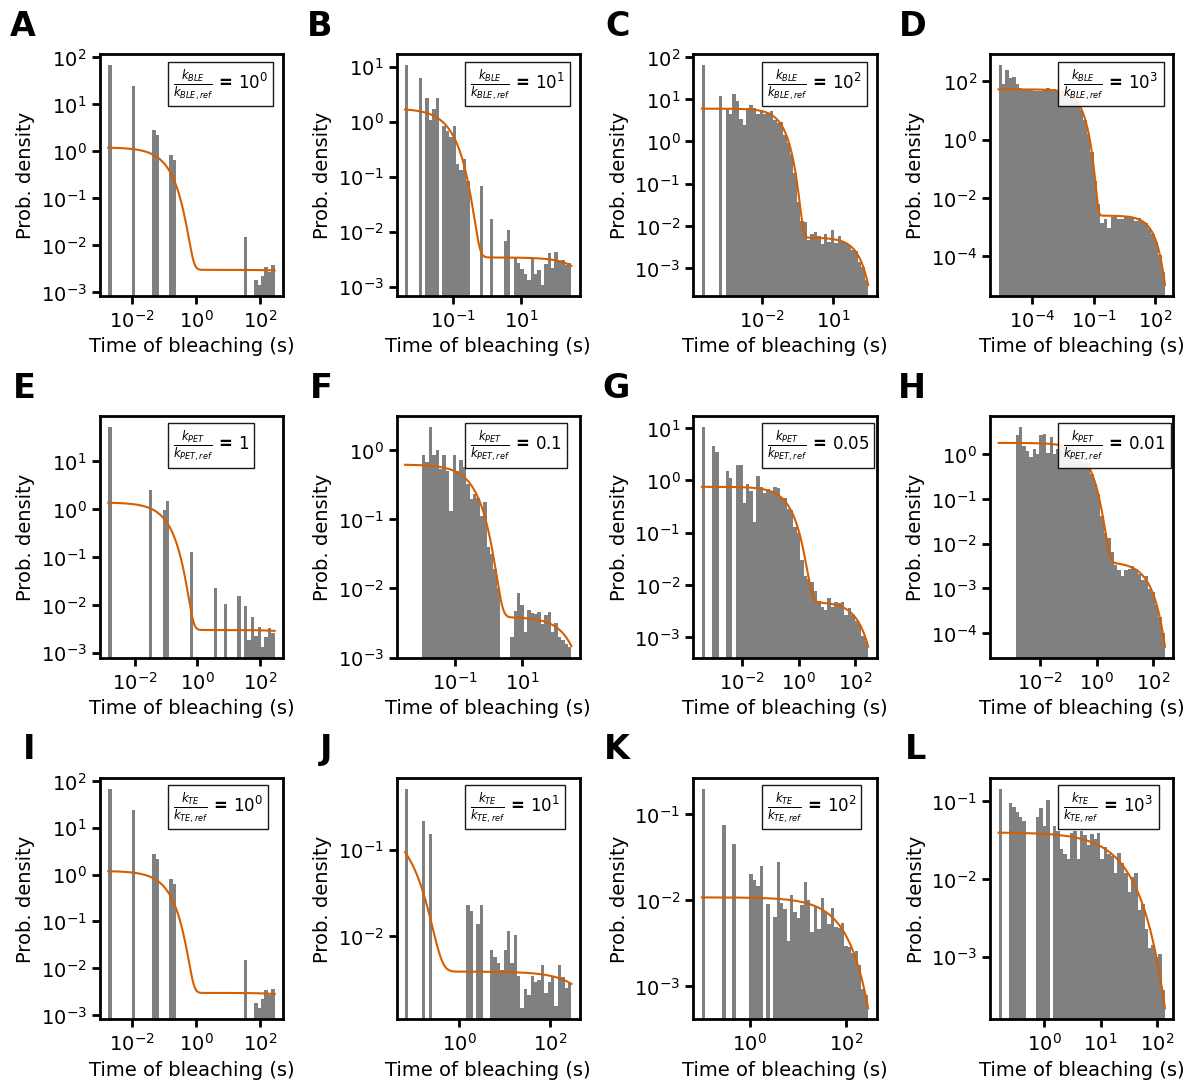

In [ ]:
red = "#D55E00"
color = 'grey'

import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['axes.linewidth'] = 2
gs = plt.GridSpec(3, 4)
fig = plt.figure(figsize=(12, 11))
label1 = [r'$\frac{k_{BLE}}{k_{BLE,ref}}$',
          r'$\frac{k_{PET}}{k_{PET,ref}}$',
          r'$\frac{k_{TE}}{k_{TE,ref}}$']
label2 = [[r'$10^{0}$', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'],
          [r'$1$', r'$0.1$', r'$0.05$', r'$0.01$'],
          [r'$10^{0}$', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$']]

for i, (bleaching_times_all, parameters_all_fit_cdf) in enumerate(
        zip([bleaching_times_all_A, bleaching_times_all_B, bleaching_times_all_C],
            [parameters_all_fit_cdf_A, parameters_all_fit_cdf_B, parameters_all_fit_cdf_C])):
    for j, (bl_times, parameters) in enumerate(zip(bleaching_times_all, parameters_all_fit_cdf)):
        pi, lambda1, lambda2 = parameters
        data = bl_times[:, 0][~np.isnan(bl_times[:, 0])]
        bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
        x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 1000)
        ax = fig.add_subplot(gs[i, j])
        fi.universal_figure(type_='hist', data=data, axes=ax, density=True, color=color, bins=bins)
        fi.universal_figure(type_='line',  
                            data=[x, dist.two_expon_mixture_pdf(x, lambda1, lambda2, pi)], 
                            axes=ax, yscale='log', xscale='log', xlabel='Time of bleaching (s)',
                            ylabel='Prob. density', color=red, fontsize=14)
        props = dict(boxstyle='square', facecolor='white', alpha=0.9, edgecolor='black')
        ax.text(0.4, 0.95, f'{label1[i]} = {label2[i][j]}', transform=ax.transAxes, fontsize=12,
                fontweight='bold', va='top', ha='left', bbox=props)
        
axes = fig.get_axes()
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']
for i, axis in enumerate(axes):
    offset = -0.35
    axis.text(offset, 1.05, letters[i], transform=axis.transAxes, fontsize=24, 
              fontweight='bold', va='bottom', ha='right')
fig.tight_layout()

fig.savefig('fingerprint_1f_suppl2.png', dpi=300, bbox_inches='tight', pad_inches=0.1)